<a href="https://colab.research.google.com/github/kgerman222/HW-Week-1-4-Reflection-Code-Compilation/blob/main/HW_Reflection_Week_5_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Homework 5

In [1]:
import numpy as np
import pandas as pd

# Reproducible generator for the whole notebook
rng = np.random.default_rng(0)

In [2]:
def make_data(num=100000, rng=rng):
    difficulty = rng.uniform(0, 1, (num,))
    speed = np.maximum(rng.normal(15, 5, (num,)) - difficulty * 10, 0)
    accident = np.minimum(
        np.maximum(0.03 * speed + 0.4 * difficulty + rng.normal(0, 0.3, (num,)), 0),
        1,
    )
    return pd.DataFrame({'difficulty': difficulty,
                         'speed': speed,
                         'accident': accident})

df = make_data()
df.head()

,difficulty,speed,accident
0,0.636962,4.406245,0.106171
1,0.269787,16.061462,0.334104
2,0.040974,15.942585,0.803100
3,0.016528,14.592084,0.065198
4,0.813270,11.060270,0.663822


In [3]:
def x_coefficient(df, predictors, target='speed'):
    X = np.column_stack([np.ones(len(df))] + [df[p].values for p in predictors])
    beta, *_ = np.linalg.lstsq(X, df[target].values, rcond=None)
    return beta[1]

print('difficulty coef (Y ~ X):    ', round(x_coefficient(df, ['difficulty']), 4))
print('difficulty coef (Y ~ X + Z):', round(x_coefficient(df, ['difficulty', 'accident']), 4))

difficulty coef (Y ~ X):     -9.6276
difficulty coef (Y ~ X + Z): -10.2643


### Q1 — Y ~ X (ignore collider)

In [4]:
N_TRIALS = 300

q1 = [x_coefficient(make_data(), ['difficulty']) for _ in range(N_TRIALS)]
q1_mean = np.mean(q1)

print(f"Q1 average coefficient on X over {N_TRIALS} datasets: {q1_mean:.4f}")
print(f"  (std of the per-dataset estimates: {np.std(q1):.4f})")

Q1 average coefficient on X over 300 datasets: -9.6618
  (std of the per-dataset estimates: 0.0537)


### Q2 — Y ~ X + Z (condition on collider)

In [5]:
q2 = [x_coefficient(make_data(), ['difficulty', 'accident']) for _ in range(N_TRIALS)]
q2_mean = np.mean(q2)

print(f"Q2 average coefficient on X over {N_TRIALS} datasets: {q2_mean:.4f}")
print(f"  (std of the per-dataset estimates: {np.std(q2):.4f})")
print()
print(f"Q1 (ignore Z):   {q1_mean:.4f}")
print(f"Q2 (control Z):  {q2_mean:.4f}")
print(f"Shift from conditioning on the collider: {q2_mean - q1_mean:+.4f}")

Q2 average coefficient on X over 300 datasets: -10.3277
  (std of the per-dataset estimates: 0.0487)

Q1 (ignore Z):   -9.6618
Q2 (control Z):  -10.3277
Shift from conditioning on the collider: -0.6660


In [6]:
def make_data_clean(num=100000, rng=rng):
    difficulty = rng.uniform(0, 1, (num,))
    speed = rng.normal(15, 5, (num,)) - difficulty * 10            # true slope = -10, no floor
    accident = 0.03 * speed + 0.4 * difficulty + rng.normal(0, 0.3, (num,))  # collider, no clip
    return pd.DataFrame({'difficulty': difficulty, 'speed': speed, 'accident': accident})

clean_q1 = np.mean([x_coefficient(make_data_clean(), ['difficulty']) for _ in range(N_TRIALS)])
clean_q2 = np.mean([x_coefficient(make_data_clean(), ['difficulty', 'accident']) for _ in range(N_TRIALS)])

print(f"True causal slope:                 -10.000")
print(f"Ignore Z   (Y ~ X)      -> coef:  {clean_q1:.4f}")
print(f"Control Z  (Y ~ X + Z)  -> coef:  {clean_q2:.4f}")

True causal slope:                 -10.000
Ignore Z   (Y ~ X)      -> coef:  -10.0010
Control Z  (Y ~ X + Z)  -> coef:  -10.6658


## Homework 6


In [7]:
import numpy as np
import pandas as pd

pd.set_option("display.float_format", lambda v: f"{v:.4f}")

df = pd.read_csv("/content/homework_6.1.csv")
print(df.shape)
df.head()

(1000, 3)


,Z,X,Y
0,0.5488,0,-0.8232
1,0.7152,1,0.8424
2,0.6028,1,0.8986
3,0.5449,0,-0.8173
4,0.4237,0,-0.6355


In [8]:
print("Correlation matrix:")
print(df.corr(), "\n")

print("Mean Y by treatment group:")
print(df.groupby("X")["Y"].agg(["mean", "count"]), "\n")

naive_diff = df.loc[df.X == 1, "Y"].mean() - df.loc[df.X == 0, "Y"].mean()
print(f"Naive (confounded) difference in means: {naive_diff:.4f}")

Correlation matrix:
       Z      X      Y
Z 1.0000 0.5123 0.1912
X 0.5123 1.0000 0.9289
Y 0.1912 0.9289 1.0000 

Mean Y by treatment group:
     mean  count
X               
0 -0.5246    509
1  0.8762    491 

Naive (confounded) difference in means: 1.4008


In [9]:
def fit_line(sub):
    A = np.column_stack([np.ones(len(sub)), sub.Z.values])
    coef, *_ = np.linalg.lstsq(A, sub.Y.values, rcond=None)
    pred = A @ coef
    r2 = 1 - ((sub.Y.values - pred) ** 2).sum() / ((sub.Y.values - sub.Y.mean()) ** 2).sum()
    return coef, r2

for x in (0, 1):
    (b0, b1), r2 = fit_line(df[df.X == x])
    print(f"X={x}:  E[Y|Z] = {b0:+.4f} {b1:+.4f}*Z     (R^2 = {r2:.4f})")

X=0:  E[Y|Z] = +0.0000 -1.5000*Z     (R^2 = 1.0000)
X=1:  E[Y|Z] = +1.2000 -0.5000*Z     (R^2 = 1.0000)


In [10]:
df["Y0"]  = -1.5 * df.Z
df["Y1"]  =  1.2 - 0.5 * df.Z
df["ITE"] = df.Y1 - df.Y0

print(df[["Z", "X", "Y", "Y0", "Y1", "ITE"]].head())
print(f"\nITE range: [{df.ITE.min():.4f}, {df.ITE.max():.4f}]")

       Z  X       Y      Y0     Y1    ITE
0 0.5488  0 -0.8232 -0.8232 0.9256 1.7488
1 0.7152  1  0.8424 -1.0728 0.8424 1.9152
2 0.6028  1  0.8986 -0.9041 0.8986 1.8028
3 0.5449  0 -0.8173 -0.8173 0.9276 1.7449
4 0.4237  0 -0.6355 -0.6355 0.9882 1.6237

ITE range: [1.2005, 2.1998]


### Q1

In [11]:
ATE = df.ITE.mean()
print(f"ATE = {ATE:.4f}")

ATE = 1.6959


### Q2

In [12]:
ATT = df.loc[df.X == 1, "ITE"].mean()
print(f"ATT = {ATT:.4f}")

ATT = 1.8475


### Q3

In [13]:
ATU = df.loc[df.X == 0, "ITE"].mean()
print(f"ATU = {ATU:.4f}")

ATU = 1.5497


### Q4

In [14]:
opts = {"A": 2.172, "B": 1.480, "C": 1.134, "D": 0.8935}
def nearest(v):
    k = min(opts, key=lambda o: abs(opts[o] - v))
    return k, opts[k], abs(opts[k] - v)

# Optimal rule: treat where Y1 > Y0  (everyone here)
opt_outcome = np.maximum(df.Y0, df.Y1)          # = Y1 for every unit

candidates = {
    "Gain of optimal rule over treating nobody  E[max]-E[Y0] (= ATE here)": (opt_outcome - df.Y0).mean(),
}

for name, val in candidates.items():
    print("{val:8.4f}")

{val:8.4f}


## Homework 7


In [15]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

rng_seed = 7
np.random.seed(rng_seed)

### Q1–2 — Correlation of X with omitted error term

In [16]:
np.random.seed(rng_seed)

W = np.random.normal(0, 1, (1000,))
X = W + np.random.normal(0, 1, (1000,))
Z = np.random.normal(0, 1, (1000,))
eps_Y = np.random.normal(0, 1, (1000,))
Y = X + Z + W + eps_Y

structural_error = W + eps_Y
print("Corr(X, W + eps_Y), single draw:",
      round(np.corrcoef(X, structural_error)[0, 1], 3))

corrs = []
for _ in range(2000):
    W = np.random.normal(0, 1, 1000)
    X = W + np.random.normal(0, 1, 1000)
    eps_Y = np.random.normal(0, 1, 1000)
    corrs.append(np.corrcoef(X, W + eps_Y)[0, 1])
print("Mean corr over 2000 draws:", round(np.mean(corrs), 3))

Corr(X, W + eps_Y), single draw: 0.479
Mean corr over 2000 draws: 0.5


In [17]:
# Corr = Var(W) / sqrt(Var(X) * Var(W + eps_Y)) = 1 / sqrt(2 * 2) = 0.5
print("Theoretical Corr(X, error) =", 1 / np.sqrt(2 * 2))

Theoretical Corr(X, error) = 0.5


### Q3 — X coefficient at constant W

In [18]:
df = pd.read_csv("/content/homework_7.1.csv", index_col=0)
df.head()

,X,W,Z,Y
0,1.1371,1.2218,0.3278,1.9445
1,-0.1129,0.4658,0.5996,0.6555
2,2.0778,1.7954,-0.0634,5.9344
3,0.4564,-0.5122,1.1774,-0.1881
4,-1.0124,0.0800,-0.2757,-0.5338


In [19]:
def x_coef_at(df, w0, width=0.2):
    sub = df[np.abs(df["W"] - w0) < width]
    design = sm.add_constant(sub[["X", "Z"]])
    fit = sm.OLS(sub["Y"], design).fit()
    return fit.params["X"], len(sub)

print(f"{'W near':>7} | {'n':>5} | {'X coef':>7}")
print("-" * 26)
results = {}
for w0 in [-1, 0, 1]:
    b, n = x_coef_at(df, w0)
    results[w0] = b
    print(f"{w0:>7} | {n:>5} | {b:>7.3f}")

 W near |     n |  X coef
--------------------------
     -1 |   967 |   0.870
      0 |  1546 |   1.418
      1 |   909 |   1.934


In [20]:
# Robustness across window widths
for width in [0.15, 0.2, 0.3]:
    row = [round(x_coef_at(df, w0, width)[0], 3) for w0 in [-1, 0, 1]]
    print(f"width +/-{width}:  W=-1,0,1 -> {row}")

# Explicit interaction term on the full data set
df2 = df.copy()
df2["X_times_W"] = df2["X"] * df2["W"]
design = sm.add_constant(df2[["X", "Z", "W", "X_times_W"]])
fit = sm.OLS(df2["Y"], design).fit()
print("\nFull-data model Y ~ X + Z + W + X*W :")
print(fit.params.round(3))

width +/-0.15:  W=-1,0,1 -> [np.float64(0.87), np.float64(1.381), np.float64(1.963)]
width +/-0.2:  W=-1,0,1 -> [np.float64(0.87), np.float64(1.418), np.float64(1.934)]
width +/-0.3:  W=-1,0,1 -> [np.float64(0.918), np.float64(1.428), np.float64(1.931)]

Full-data model Y ~ X + Z + W + X*W :
const        0.0060
X            1.3960
Z           -0.5930
W            1.2030
X_times_W    0.4970
dtype: float64


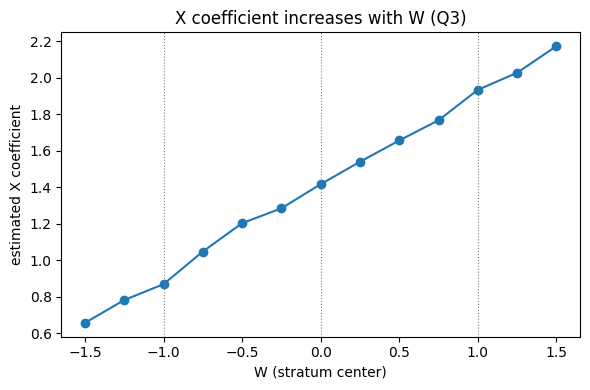

In [21]:
# Visualize: X-coefficient vs the W stratum
w_grid = np.linspace(-1.5, 1.5, 13)
coefs = [x_coef_at(df, w0, 0.2)[0] for w0 in w_grid]

plt.figure(figsize=(6, 4))
plt.plot(w_grid, coefs, "o-")
for w0 in [-1, 0, 1]:
    plt.axvline(w0, color="gray", ls=":", lw=0.8)
plt.xlabel("W (stratum center)")
plt.ylabel("estimated X coefficient")
plt.title("X coefficient increases with W (Q3)")
plt.tight_layout()
plt.show()

### Q4

In [22]:
def make_error(corr_const, num):
    err = list()
    prev = np.random.normal(0, 1)
    for n in range(num):
        prev = corr_const * prev + (1 - corr_const) * np.random.normal(0, 1)
        err.append(prev)
    return np.array(err)


def run_trials(corr_const, n=500, trials=600, true_b=2.0):
    """Fit Y ~ X over many trials; return (i) SD of b-hat and (ii) mean reported SE."""
    b_hats, reported_ses = [], []
    for _ in range(trials):
        X = make_error(corr_const, n)              # treatment uses correlated error
        Y = true_b * X + make_error(corr_const, n) # outcome error also correlated
        design = sm.add_constant(X)
        fit = sm.OLS(Y, design).fit()
        b_hats.append(fit.params[1])               # X coefficient
        reported_ses.append(fit.bse[1])            # OLS standard error of X coef
    sd_of_estimate = np.std(b_hats)                # (i)
    mean_reported_se = np.mean(reported_ses)       # (ii)
    return sd_of_estimate, mean_reported_se


np.random.seed(rng_seed)
print(f"{'corr_const':>10} | {'(i) SD of b':>11} | {'(ii) mean SE':>12} | {'(i)/(ii)':>8}")
print("-" * 52)
ratios = {}
for cc in [0.2, 0.5, 0.8]:
    sd_i, se_ii = run_trials(cc)
    ratios[cc] = sd_i / se_ii
    print(f"{cc:>10} | {sd_i:>11.4f} | {se_ii:>12.4f} | {sd_i/se_ii:>8.3f}")

corr_const | (i) SD of b | (ii) mean SE | (i)/(ii)
----------------------------------------------------
       0.2 |      0.0464 |       0.0447 |    1.037
       0.5 |      0.0585 |       0.0447 |    1.309
       0.8 |      0.0990 |       0.0448 |    2.212


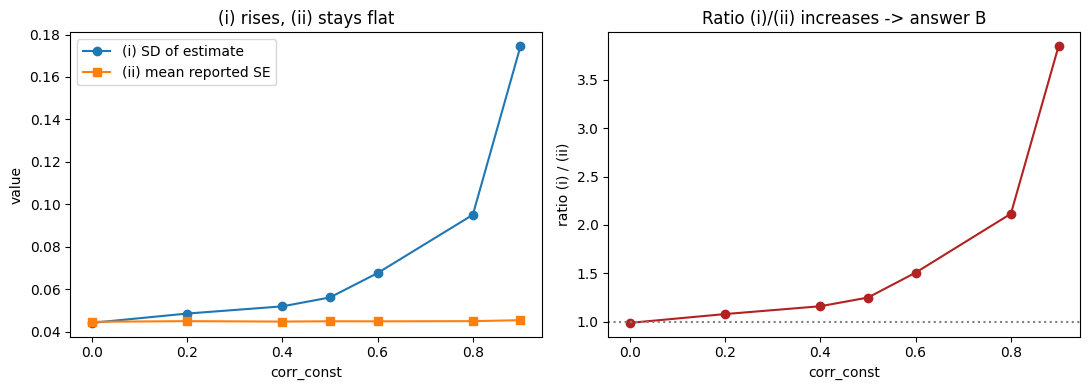

In [23]:
# Plot to visualize
np.random.seed(rng_seed)
ccs = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9]
sds, ses = [], []
for cc in ccs:
    s_i, s_ii = run_trials(cc, trials=400)
    sds.append(s_i); ses.append(s_ii)

ratio = np.array(sds) / np.array(ses)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ccs, sds, "o-", label="(i) SD of estimate")
ax[0].plot(ccs, ses, "s-", label="(ii) mean reported SE")
ax[0].set_xlabel("corr_const"); ax[0].set_ylabel("value")
ax[0].set_title("(i) rises, (ii) stays flat"); ax[0].legend()

ax[1].plot(ccs, ratio, "o-", color="firebrick")
ax[1].axhline(1, color="gray", ls=":")
ax[1].set_xlabel("corr_const"); ax[1].set_ylabel("ratio (i) / (ii)")
ax[1].set_title("Ratio (i)/(ii) increases -> answer B")
plt.tight_layout(); plt.show()

## Homework 8

In [24]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from scipy.spatial.distance import mahalanobis

np.set_printoptions(precision=4, suppress=True)

In [25]:
df1 = pd.read_csv("/content/homework_8.1.csv", index_col=0)
df1.head()

,X,Y,Z
0,1,4.1092,1.7641
1,0,2.2595,0.4002
2,0,-0.6476,0.9787
3,0,2.1061,2.2409
4,1,3.5835,1.8676


In [26]:
Z = df1[["Z"]].values   # 2D design matrix for sklearn
X = df1["X"].values
Y = df1["Y"].values

# Estimate propensity scores: Z predicts X
logit = LogisticRegression()
logit.fit(Z, X)
P = logit.predict_proba(Z)[:, 1]   # P(X = 1 | Z)

# Inverse-probability weights
weights = np.where(X == 1, 1.0 / P, 1.0 / (1.0 - P))

# Weighted (Hajek-normalized) mean outcome in each arm
treated_mask = (X == 1)
control_mask = (X == 0)

mu_treated = np.sum(weights[treated_mask] * Y[treated_mask]) / np.sum(weights[treated_mask])
mu_control = np.sum(weights[control_mask] * Y[control_mask]) / np.sum(weights[control_mask])

ate_ipw = mu_treated - mu_control
print(f"Weighted mean outcome (treated): {mu_treated:.4f}")
print(f"Weighted mean outcome (control): {mu_control:.4f}")
print(f"IPW ATE: {ate_ipw:.4f}")

Weighted mean outcome (treated): 2.2367
Weighted mean outcome (control): -0.0376
IPW ATE: 2.2743


In [27]:
first_three = P[:3]
print("Propensity scores of the first three items:", np.round(first_three, 2))

Propensity scores of the first three items: [0.84 0.58 0.71]


In [28]:
df2 = pd.read_csv("/content/homework_8.2.csv", index_col=0)
df2.head()

,X,Y,Z1,Z2
0,1,4.6521,1.7641,2.3200
1,1,2.5902,0.4002,1.2926
2,1,3.8990,0.9787,0.5564
3,1,5.8572,2.2409,2.3456
4,1,3.6475,1.8676,2.0956


In [29]:
# 2 x N matrix of all Z1 and all Z2, then 2x2 covariance, then invert
Z_2xN = df2[["Z1", "Z2"]].values.T      # shape (2, N)
cov = np.cov(Z_2xN)                      # 2 x 2 covariance
VI = np.linalg.inv(cov)                  # inverse covariance for Mahalanobis
print("Covariance:\n", cov)
print("Inverse covariance:\n", VI)

Covariance:
 [[0.9752 0.9451]
 [0.9451 1.8532]]
Inverse covariance:
 [[ 2.0273 -1.0339]
 [-1.0339  1.0668]]


In [30]:
treated = df2[df2["X"] == 1]
control = df2[df2["X"] == 0]

Zt = treated[["Z1", "Z2"]].values
Yt = treated["Y"].values
Zc = control[["Z1", "Z2"]].values
Yc = control["Y"].values

matched_control_Y = np.empty(len(Zt))
matched_control_idx = np.empty(len(Zt), dtype=int)
match_distance = np.empty(len(Zt))

for i in range(len(Zt)):
    dists = np.array([mahalanobis(Zt[i], Zc[j], VI) for j in range(len(Zc))])
    j = np.argmin(dists)
    matched_control_idx[i] = j
    matched_control_Y[i] = Yc[j]
    match_distance[i] = dists[j]

ate_match = np.mean(Yt - matched_control_Y)
print(f"Mahalanobis-matching ATE: {ate_match:.4f}")

Mahalanobis-matching ATE: 3.4377


In [31]:
worst = np.argmax(match_distance)

worst_treated_Z = Zt[worst]
nearest_untreated_Z = Zc[matched_control_idx[worst]]

print(f"Worst-supported treated item Z1,Z2: {np.round(worst_treated_Z, 2)}")
print(f"Its match distance:                 {match_distance[worst]:.3f}")
print(f"Nearest untreated Z1,Z2:            {np.round(nearest_untreated_Z, 2)}")

Worst-supported treated item Z1,Z2: [2.7  0.54]
Its match distance:                 1.383
Nearest untreated Z1,Z2:            [ 1.52 -1.28]
